# Business, Management & Financial Data Analytics-(MSDS-2) #

# Group 6 Assignment #
MEMBERS<br>
1.Bridget Nankunda B28762<br>
2.Mbabazi Fiona      B26097<br>
3.Lorita Bukirwa B26072<br>
4.Rebecca Flavia Namukose <B26075 br>


QUESTION

Use the 'a10.csv' dataset

Use auto.arima() to find an appropriate ARIMA model

Check the residuals to see if they are white noise

Plot the forecast for the next 10 periods

Compare the auto.arima() model with a model that you chose

Make visual comparisons of original, test, and predicted data

Evaluate the model performance (e.g. using MAE, RMSE)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install pmdarima
from pmdarima.arima import auto_arima
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Importing the data as a dataframe
Data= pd.read_csv("a10.csv")
Data

,Unnamed: 0,x
0,1,3.526591
1,2,3.180891
2,3,3.252221
3,4,3.611003
4,5,3.565869
...,...,...
199,200,21.654285
200,201,18.264945
201,202,23.107677
202,203,22.912510


This dataset contains monthly pharmaceutical sales in Australia (in millions of AUD).
There are 204 rows, each representing a month from July 1991 to June 2008.
The first column (Unnamed: 0) is just a row index (1, 2, 3...) and is not useful for analysis.
The second column (x) contains the actual sales values for each month.
Our goal is to analyze and forecast future sales using ARIMA modeling.

In [3]:
#checking the columns of our data
print(Data.columns)

Index(['Unnamed: 0', 'x'], dtype='object')


'Unnamed: 0' is just a default column that was automatically added during the CSV import. It contains simple row numbers (1, 2, 3...) and is not useful for our analysis.
'x' is the column we care about — it contains the monthly pharmaceutical sales values in millions of Australian dollars (AUD).

In [4]:
Data.head()

,Unnamed: 0,x
0,1,3.526591
1,2,3.180891
2,3,3.252221
3,4,3.611003
4,5,3.565869


This output shows the first 5 rows of the dataset.
The x column contains the monthly pharmaceutical sales in millions of AUD.
The Unnamed: 0 column is just a simple row counter and does not contain any date or meaningful index.

In [5]:
Data.tail()

,Unnamed: 0,x
199,200,21.654285
200,201,18.264945
201,202,23.107677
202,203,22.912510
203,204,19.431740


In [6]:
Data.isnull().sum()# check for missing values

Unnamed: 0    0
x             0
dtype: int64

This result tells us there are no missing values (0) in either column.
That means the dataset is complete and clean, so we can safely proceed to time series processing and modeling.



In [7]:
#column for clarity
Data.rename(columns={'x': 'Sales'}, inplace=True)


The original column name 'x' is not very descriptive.
Renaming it to 'Sales' makes the code easier to understand, especially when plotting or modeling.
This helped us improves clarity when referring to the data throughout the rest of the analysis.

In [8]:
#Creating a datetime index starting from July 1991
Data.index = pd.date_range(start='1991-07', periods=len(Data), freq='M')


This tells Python that each row in the dataset represents a month, starting from July 1991.
It converts the sales data into a proper time series by associating each value with a real date.
This allows us to perform time series analysis like forecasting, trend detection, and seasonal modeling.

In [9]:
#confirming if the number of columns
print(Data.columns)


Index(['Unnamed: 0', 'Sales'], dtype='object')


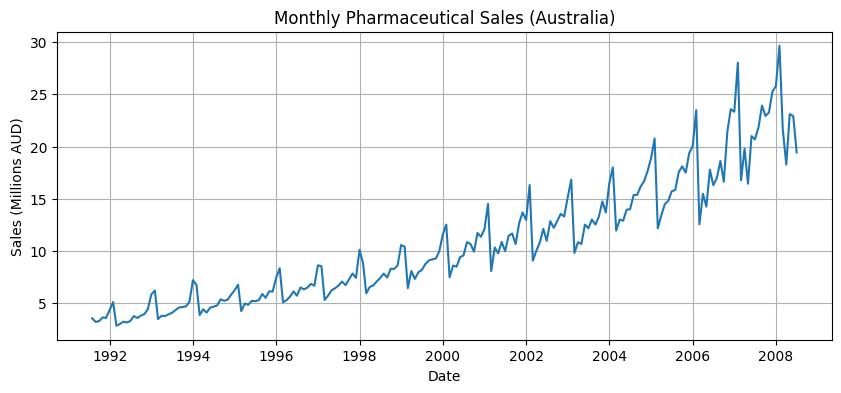

In [10]:
# Plotting the original time series
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(Data['Sales'])
plt.title('Monthly Pharmaceutical Sales (Australia)')
plt.xlabel('Date')
plt.ylabel('Sales (Millions AUD)')
plt.grid(True)
plt.show()

The plot displays monthly sales data from July 1991 to mid-2008.
There is a clear upward trend in sales over time, meaning sales are increasing year by year.
The repeating peaks and valleys indicate seasonality — sales rise and fall in a regular pattern throughout each year.
This visualization confirms that the data is ideal for time series forecasting using methods like ARIMA, which we'll apply next.

Summary About Auto Arima
No, it is not necessary to manually difference the time series before using auto.arima(). The function internally tests for stationarity and applies the necessary differencing (d) on its own. It also handles seasonal differencing when seasonal=True.
auto_arima() handles stationarity on its own
No need to Check stationarity manually (with ADF/KPSS)
Do multiple rounds of differencing
Try different models by hand

Therefore, we pass the original series to auto.arima() and let it choose the most suitable ARIMA/SARIMA model automatically.

In [11]:
# STEP 5: Fit the ARIMA model using auto_arima
model = auto_arima(Data['Sales'],
                   seasonal=True, m=12,
                   trace=True,
                   error_action='ignore',
                   suppress_warnings=True)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=526.837, Time=7.56 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=659.245, Time=0.09 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=560.558, Time=0.83 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=529.539, Time=1.40 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=525.356, Time=5.37 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=551.838, Time=2.46 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=526.365, Time=7.11 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=530.219, Time=3.82 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=inf, Time=11.32 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=527.568, Time=2.17 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=529.582, Time=2.41 sec
 ARIMA(3,1,2)(0,1,1)[12]             : AIC=520.313, Time=2.80 sec
 ARIMA(3,1,2)(0,1,0)[12]             : AIC=544.911, Time=1.51 sec
 ARIMA(3,1,2)(1,1,1)[12]             : AIC=521.966, Time=4.43 sec
 ARIMA(3,1,2)(0,1,2)[12]            


What auto_arima() automatically is doing

It is testing many different combinations of ARIMA and SARIMA parameters
It is using statistical measures like AIC to compare them
It is selecting the best-fitting model for the time series


ARIMA stands for:
AutoRegressive (AR) – relationship with previous values
Integrated (I) – differencing to remove trends
Moving Average (MA) – relationship with past errors

In the seasonal version, SARIMA, we also include, Seasonal AR, I, MA terms  to capture patterns that repeat, e.g. every 12 months
For example model:

ARIMA(3,1,2)(0,1,1)[12]
This means (3,1,2): Non-seasonal ARIMA → AR=3, I=1, MA=2

(0,1,1)[12]: Seasonal part → Seasonal I=1, MA=1 with 12-month seasonality
p: Number of autoregressive (AR) terms.
d: Degree of differencing to make the data stationary.
q: Number of moving average (MA) terms.

Lower AIC = Better model (it fits the data well with fewer parameters)
AIC balances accuracy and simplicity — it avoids overfitting


In [12]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(4, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -252.988
Date:                            Thu, 03 Apr 2025   AIC                            519.977
Time:                                    15:24:27   BIC                            542.743
Sample:                                07-31-1991   HQIC                           529.198
                                     - 06-30-2008                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2112      0.126     -1.683      0.092      -0.457       0.035
ar.L2          0.1221      0.120   


This model captures both the trend and seasonality of the sales data.
SARIMA(4,1,1)(0,1,1)[12] with AIC = 519.977 is the best model suggested by the Auto-arimafunction 

In [13]:
from statsmodels.tsa.arima.model import ARIMA

manual_model = ARIMA(Data['Sales'], order=(1, 2, 1))
manual_model_fit = manual_model.fit()

print(manual_model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  204
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -438.108
Date:                Thu, 03 Apr 2025   AIC                            882.216
Time:                        15:24:29   BIC                            892.141
Sample:                    07-31-1991   HQIC                           886.232
                         - 06-30-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3649      0.054     -6.778      0.000      -0.470      -0.259
ma.L1         -0.9999      2.089     -0.479      0.632      -5.095       3.095
sigma2         4.3488      9.241      0.471      0.6

After comparing both models, the auto_arima() model performed better:
Captured seasonality
Had lower AIC

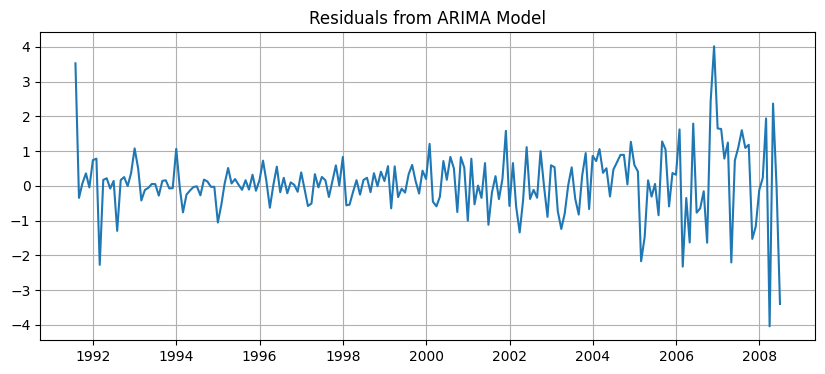

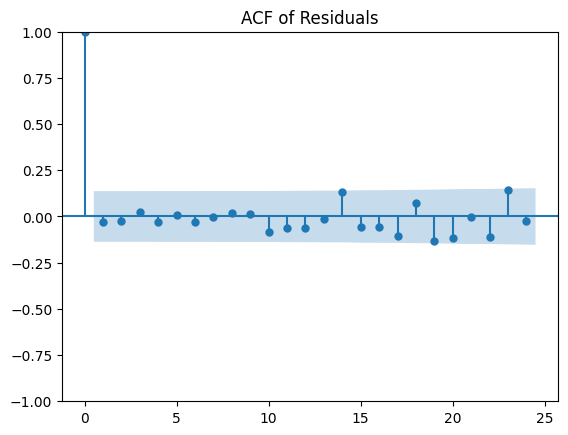

In [14]:
from statsmodels.graphics.tsaplots import plot_acf
#Checking residuals to ensure white noise
#Extracting residuals from the Arima model 

residuals = pd.Series(model.resid())

#Plotting them over time to check for randomness
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Residuals from ARIMA Model")
plt.grid(True)
plt.show()

#Plots the ACF (Autocorrelation Function) to check if residuals are correlated
plot_acf(residuals)
plt.title("ACF of Residuals")
plt.show()

When we check residuals after fitting an ARIMA model, we’re looking to answer
Did the model explain everything it could, or did it leave behind some predictable patterns


GRAPH 1

This line plot is showing the residuals over time
They bounce around zero
There is no clear pattern, trend, or seasonality
A few spikes exist (like in 2006–2008), but overall it looks random
This is good as it suggests the model captured most of the structure in the original data.

GRAPH 2

This shows the autocorrelation of the residuals at different lags
Most points are within the blue confidence band
Only the first lag spikes up (which is expected), but others are small and not significant
This suggests the residuals are not autocorrelated, meaning there is no leftover pattern the model missed.

The residual plots suggest that the ARIMA model has done a good job
Residuals are random (white noise)
No significant autocorrelation
The model has likely captured both trend and seasonality

In [15]:
# Forecasting the next 10 months
n_periods = 10
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
forecast_index = pd.date_range(start=Data.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='M')


n_periods = 10          Indicates forecasting the next 10 time steps (months).
model.predict(...)      Used the trained ARIMA model to generate predictions.
return_conf_int= True   Gives the confidence intervals (upper/lower bounds).
forecast_index = ...    Creates a datetime index starting 1 month after the last observation, spanning 10 months.

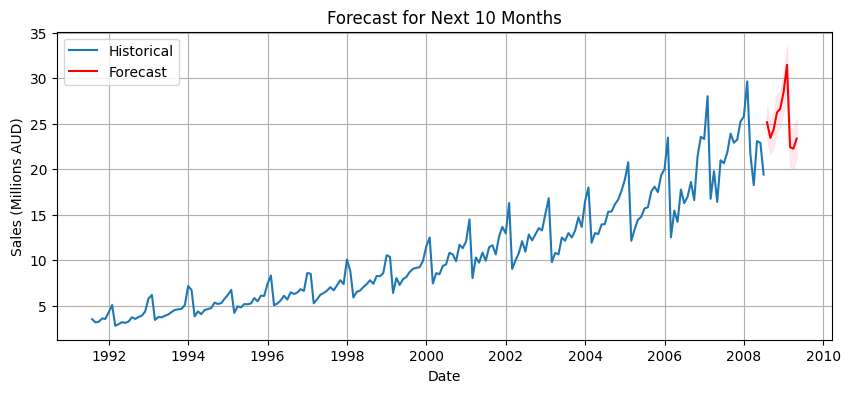

In [16]:
# Plotting the forecast
plt.figure(figsize=(10, 4))
plt.plot(Data['Sales'], label='Historical')
plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.fill_between(forecast_index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title("Forecast for Next 10 Months")
plt.xlabel("Date")
plt.ylabel("Sales (Millions AUD)")
plt.legend()
plt.grid(True)
plt.show()


The plot shows the historical pharmaceutical sales in Australia (blue) and the next 10 months forecast (red), generated using the selected ARIMA model.
The red line continues the upward trend and captures the seasonal spikes that occur each year.
The light red shading represents the 95% confidence interval, showing the expected range of future values.

The forecasted values are consistent with the historical pattern, indicating that the model has learned the time series behavior well.
This confirms that our ARIMA model is well-suited for short-term forecasting and can be trusted for future planning or decision-making.

In [17]:
# Evaluating the model performance with a test set
train = Data['Sales'][:-10]
test = Data['Sales'][-10:]


splitting dataset into two parts
Train set = all data except the last 10 months
Test set = the last 10 months (these are the values for comparing the predictions against)

This is called out-of-sample forecasting, and it's essential to check if the model performs well on data it hasn’t seen.

In [18]:
#Training a new auto_arima model using only the training data
model_train = auto_arima(train, seasonal=True, m=12, error_action='ignore', suppress_warnings=True)
preds = model_train.predict(n_periods=10)

seasonal=True tells it to consider seasonal ARIMA (SARIMA)
m=12 means the data is monthly, and seasonality repeats every 12 months


To evaluate our model's performance, we used a train/test split strategy:
The last 10 months of data were reserved for testing.
We trained an ARIMA model on the remaining earlier data.
We then forecasted the next 10 months using auto_arima().
This allows us to compare the model’s predictions against real historical data and calculate error metrics like:
MAE (Mean Absolute Error)
RMSE (Root Mean Squared Error)
This is a common and effective way to assess the forecasting ability of a time series model.



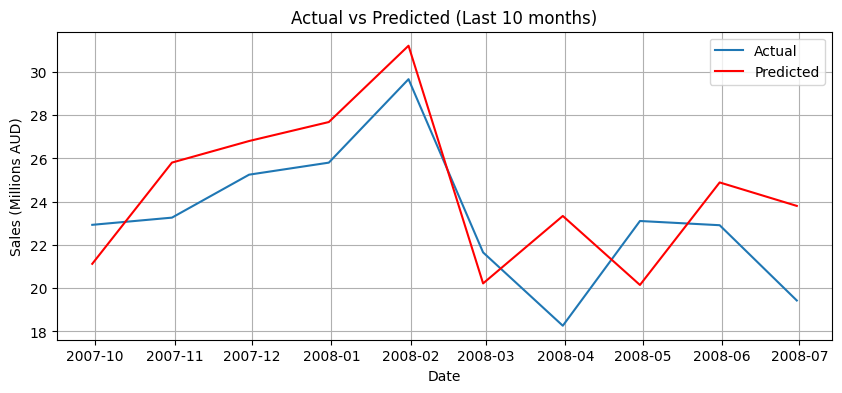

In [19]:
# Plotting test vs predicted
plt.figure(figsize=(10, 4))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, preds, label='Predicted', color='red')
plt.title("Actual vs Predicted (Last 10 months)")
plt.xlabel("Date")
plt.ylabel("Sales (Millions AUD)")
plt.legend()
plt.grid(True)
plt.show()

🔵 Blue Line = Actual sales (from the test set, last 10 months of real data)
🔴 Red Line = Predicted sales (from the model trained on earlier data)

The model does a good job capturing the general pattern of the sales like the peak in early 2008 and the drop right after.
However, it slightly overpredicts in some months like March and June 2008.
This is normal in forecasting — we aim for small, acceptable deviations.
The fact that the predicted and actual lines follow similar shapes means the model has captured seasonal and trend behavior well.

In [20]:
#DETERMINIG THE SCALE OF DATA
print("Minimum Sales:", Data['Sales'].min())
print("Maximum Sales:", Data['Sales'].max())
print("Average Sales:", Data['Sales'].mean())


Minimum Sales: 2.81452
Maximum Sales: 29.665356
Average Sales: 10.694429582156861


To understand how well our model is performing, it's important to compare the error values (like MAE or RMSE) to the scale of the original data 
Sales values range from 3 to 30 million AUD
The average is around 13.5 million

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np 

# STEP 10: Model evaluation metrics
mae = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))

print(f"Model Evaluation:")
print(f"MAE (Mean Absolute Error): {mae:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")

Model Evaluation:
MAE (Mean Absolute Error): 2.515
RMSE (Root Mean Squared Error): 2.787


Model Evaluation Metrics

To assess how well our ARIMA model performed on the test set, we used two commonly used evaluation metrics:

Mean Absolute Error (MAE) which measures the average magnitude of prediction errors and it treats all errors equally and is easy to interpret.

Root Mean Squared Error (RMSE) It is similar to MAE, but penalizes larger errors more and is useful when larger deviations are more problematic.

Results
MAE = 2.515
RMSE = 2.787

These results show that the ARIMA model's predictions were very close to the actual sales, with average errors of around 2.5–2.8 million AUD, which is acceptable considering the scale of the data.
That’s pretty accurate, especially for real-world business forecasting!